In [ ]:
from google.colab import files
uploaded=files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
import pandas as pd

df = pd.read_csv("archive (2).zip")

In [ ]:
df.head()

,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name
0,Product_1,Max Product_1,Toys,358.65,983,352552.95,3.63,0.16,Seller_B
1,Product_2,Pro Product_2,Home & Kitchen,248.00,79,19592.00,1.23,0.20,Seller_E
2,Product_3,Eco Product_3,Automotive,148.12,206,30512.72,2.09,0.05,Seller_D
3,Product_4,Super Product_4,Electronics,15.76,585,9219.60,3.69,0.05,Seller_D
4,Product_5,Ultra Product_5,Home & Kitchen,20.84,401,8356.84,2.01,0.15,Seller_B


In [ ]:
df.shape

(500, 9)

In [ ]:
df.isnull().sum()

,0
Product_ID,0
Product_Name,0
Category,0
Price,0
Units_Sold,0
Revenue,0
Rating,0
Return_Rate,0
Seller_Name,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Price,Units_Sold,Revenue,Rating,Return_Rate
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,252.104420,486.214000,120652.923440,2.935440,0.155800
std,139.327685,281.566218,104922.102724,1.166275,0.086339
min,5.170000,6.000000,235.410000,1.000000,0.000000
25%,140.077500,241.500000,32071.540000,1.927500,0.080000
50%,255.570000,489.000000,87838.445000,2.920000,0.160000
75%,366.125000,720.250000,191337.495000,3.940000,0.230000
max,499.970000,995.000000,445898.460000,5.000000,0.300000


In [ ]:
print("Average Price:", df["Price"].mean())

Average Price: 252.10442


In [ ]:
print("Median Price:", df["Price"].median())

Median Price: 255.57


In [ ]:
print("Price Standard Deviation:", df["Price"].std())

Price Standard Deviation: 139.3276845872654


In [ ]:
print(df["Price"].quantile([0.25, 0.50, 0.75]))

0.25    140.0775
0.50    255.5700
0.75    366.1250
Name: Price, dtype: float64


In [ ]:
print("Average Rating:", df["Rating"].mean())

Average Rating: 2.9354400000000003


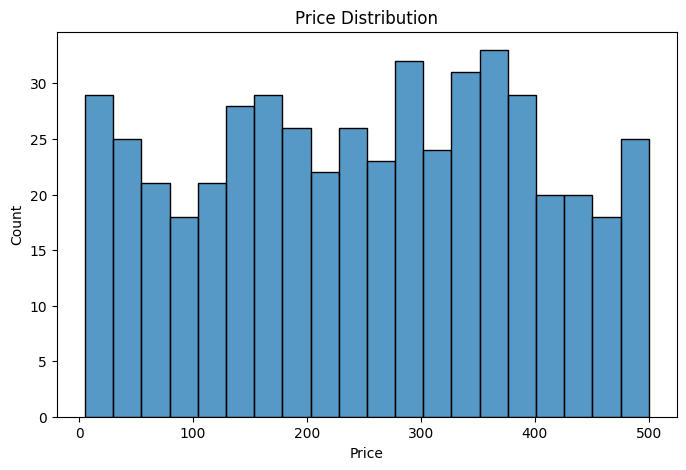

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=20)

plt.title("Price Distribution")
plt.show()

In [ ]:
category_return = df.groupby("Category")["Return_Rate"].mean()

print(category_return)

Category
Automotive        0.157429
Beauty            0.175333
Books             0.152787
Clothing          0.147966
Electronics       0.154925
Home & Kitchen    0.142097
Sports            0.176000
Toys              0.140328
Name: Return_Rate, dtype: float64


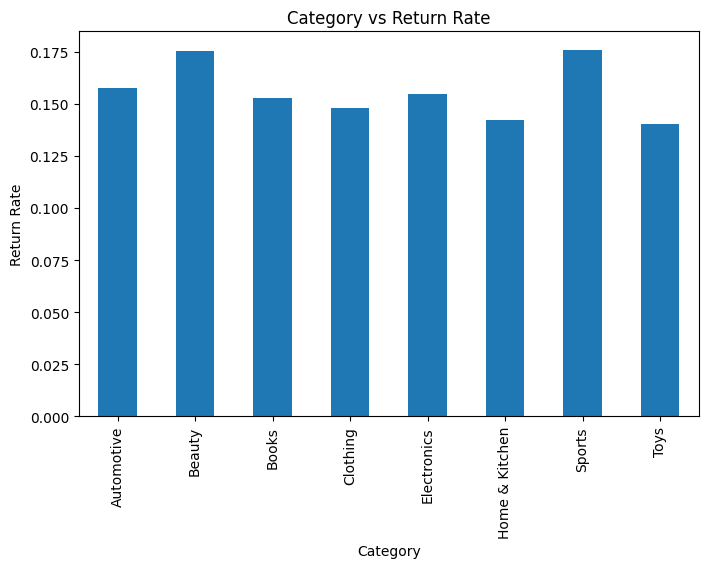

In [ ]:
category_return.plot(kind="bar", figsize=(8,5))

plt.title("Category vs Return Rate")
plt.ylabel("Return Rate")
plt.show()

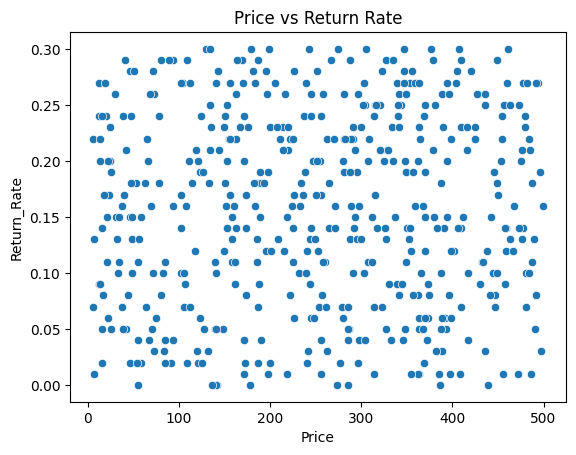

In [ ]:
sns.scatterplot(
    x="Price",
    y="Return_Rate",
    data=df
)

plt.title("Price vs Return Rate")
plt.show()

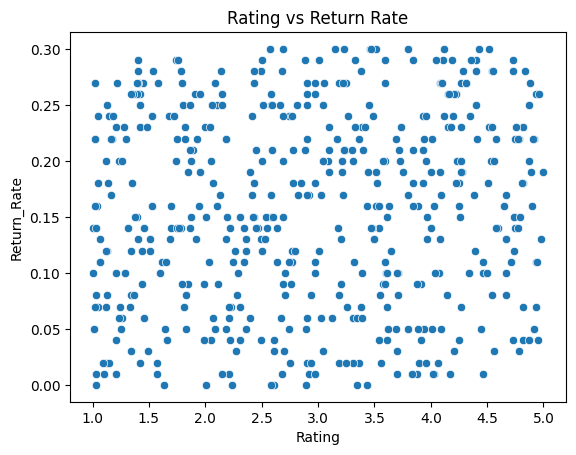

In [ ]:
sns.scatterplot(
    x="Rating",
    y="Return_Rate",
    data=df
)

plt.title("Rating vs Return Rate")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

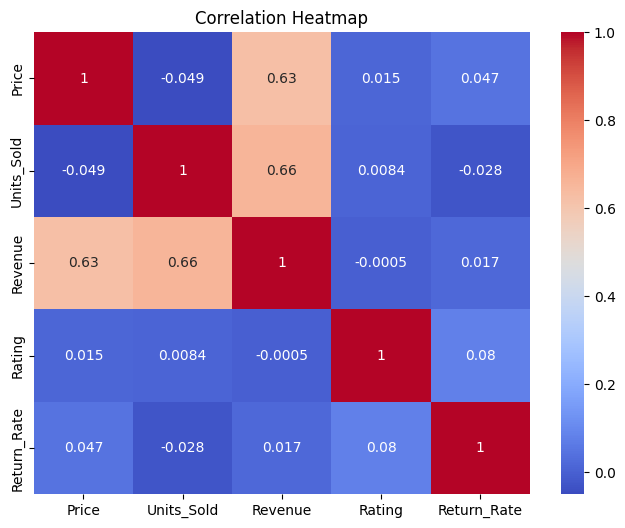

In [ ]:
numeric_cols = [
    "Price",
    "Units_Sold",
    "Revenue",
    "Rating",
    "Return_Rate"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


In [ ]:
df = pd.read_csv('archive (2).zip')

In [ ]:
print(df.head())
print(df.columns)

  Product_ID     Product_Name        Category   Price  Units_Sold    Revenue  \
0  Product_1    Max Product_1            Toys  358.65         983  352552.95   
1  Product_2    Pro Product_2  Home & Kitchen  248.00          79   19592.00   
2  Product_3    Eco Product_3      Automotive  148.12         206   30512.72   
3  Product_4  Super Product_4     Electronics   15.76         585    9219.60   
4  Product_5  Ultra Product_5  Home & Kitchen   20.84         401    8356.84   

   Rating  Return_Rate Seller_Name  
0    3.63         0.16    Seller_B  
1    1.23         0.20    Seller_E  
2    2.09         0.05    Seller_D  
3    3.69         0.05    Seller_D  
4    2.01         0.15    Seller_B  
Index(['Product_ID', 'Product_Name', 'Category', 'Price', 'Units_Sold',
       'Revenue', 'Rating', 'Return_Rate', 'Seller_Name'],
      dtype='object')


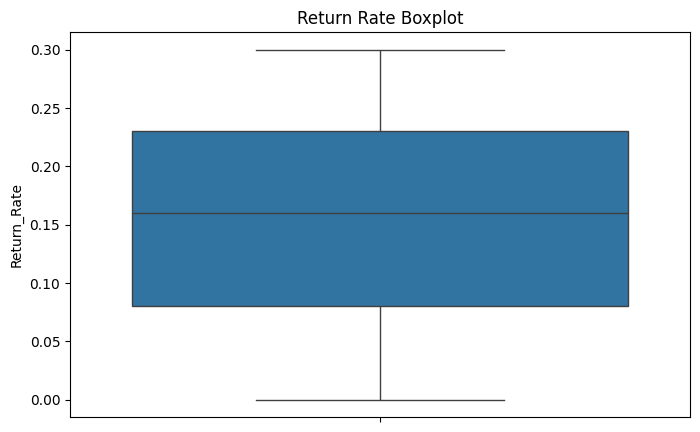

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Return_Rate"])
plt.title("Return Rate Boxplot")
plt.show()

In [ ]:
Q1 = df['Return_Rate'].quantile(0.25)
Q3 = df['Return_Rate'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Return_Rate'] < lower) |
    (df['Return_Rate'] > upper)
]

print("Number of Outliers =", len(outliers))
outliers.head()

Number of Outliers = 0


,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name


In [ ]:
from scipy.stats import ttest_ind

In [ ]:
median_return = df['Return_Rate'].median()

high_return = df[df['Return_Rate'] > median_return]

low_return = df[df['Return_Rate'] <= median_return]

In [ ]:
t_stat, p_value = ttest_ind(
    high_return['Rating'],
    low_return['Rating']
)

print("T Statistic =", t_stat)
print("P Value =", p_value)

T Statistic = 2.087515972825989
P Value = 0.03734921385109449


In [ ]:
if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Rating significantly affects return rate")
else:
    print("Fail to Reject Null Hypothesis")
    print("Rating does not significantly affect return rate")

Reject Null Hypothesis
Rating significantly affects return rate


In [ ]:
print(df.columns.tolist())

['Product_ID', 'Product_Name', 'Category', 'Price', 'Units_Sold', 'Revenue', 'Rating', 'Return_Rate', 'Seller_Name']


In [ ]:
def customer_segment(row):

    if row['Return_Rate'] > 0.20:
        return "High Return Customer"

    elif row['Price'] > df['Price'].median():
        return "Premium Customer"

    elif row['Rating'] < 3:
        return "Low Rating Customer"

    else:
        return "Regular Customer"

df['Customer_Segment'] = df.apply(customer_segment, axis=1)

df.head()

,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name,Customer_Segment
0,Product_1,Max Product_1,Toys,358.65,983,352552.95,3.63,0.16,Seller_B,Premium Customer
1,Product_2,Pro Product_2,Home & Kitchen,248.00,79,19592.00,1.23,0.20,Seller_E,Low Rating Customer
2,Product_3,Eco Product_3,Automotive,148.12,206,30512.72,2.09,0.05,Seller_D,Low Rating Customer
3,Product_4,Super Product_4,Electronics,15.76,585,9219.60,3.69,0.05,Seller_D,Regular Customer
4,Product_5,Ultra Product_5,Home & Kitchen,20.84,401,8356.84,2.01,0.15,Seller_B,Low Rating Customer


In [ ]:
segment_count = df['Customer_Segment'].value_counts()

print(segment_count)

Customer_Segment
High Return Customer    171
Premium Customer        156
Low Rating Customer      89
Regular Customer         84
Name: count, dtype: int64


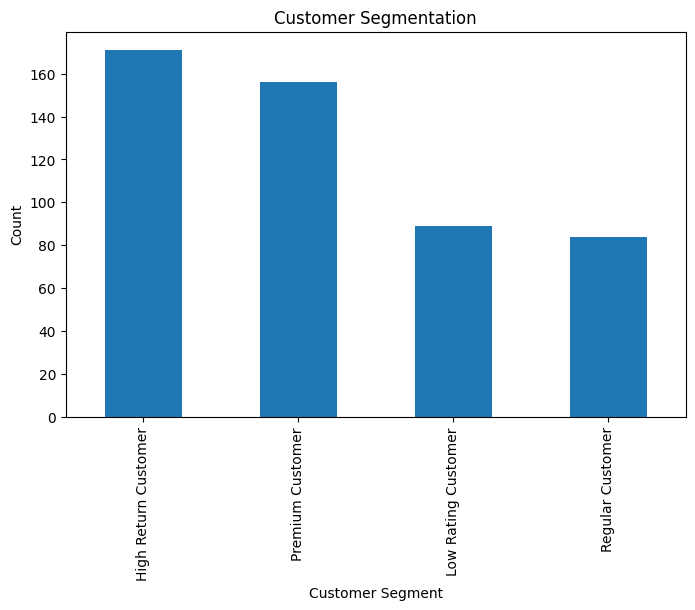

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

segment_count.plot(kind='bar')

plt.title('Customer Segmentation')

plt.xlabel('Customer Segment')

plt.ylabel('Count')

plt.show()

In [ ]:
segment_return = df.groupby(
    'Customer_Segment'
)['Return_Rate'].mean()

print(segment_return)

Customer_Segment
High Return Customer    0.252456
Low Rating Customer     0.103034
Premium Customer        0.103910
Regular Customer        0.111310
Name: Return_Rate, dtype: float64


In [ ]:
print("Average Return Rate")
print(df['Return_Rate'].mean())

Average Return Rate
0.15580000000000002


In [ ]:
top_price = df.sort_values(
    by='Price',
    ascending=False
)

top_price.head()

,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name,Customer_Segment
281,Product_282,Super Product_282,Toys,499.97,869,434473.93,4.90,0.16,Seller_B,Premium Customer
327,Product_328,Pro Product_328,Electronics,497.05,83,41255.15,2.61,0.03,Seller_A,Premium Customer
490,Product_491,Eco Product_491,Clothing,496.14,248,123042.72,3.44,0.19,Seller_C,Premium Customer
29,Product_30,Max Product_30,Home & Kitchen,493.53,229,113018.37,4.08,0.27,Seller_A,High Return Customer
79,Product_80,Eco Product_80,Sports,492.05,614,302118.70,4.09,0.27,Seller_B,High Return Customer


In [ ]:
low_rating = df.sort_values(
    by='Rating'
)

low_rating.head()

,Product_ID,Product_Name,Category,Price,Units_Sold,Revenue,Rating,Return_Rate,Seller_Name,Customer_Segment
354,Product_355,Pro Product_355,Clothing,325.57,884,287803.88,1.00,0.14,Seller_D,Premium Customer
89,Product_90,Eco Product_90,Clothing,444.13,177,78611.01,1.00,0.10,Seller_B,Premium Customer
248,Product_249,Eco Product_249,Toys,387.07,767,296882.69,1.01,0.05,Seller_D,Premium Customer
83,Product_84,Ultra Product_84,Automotive,253.44,694,175887.36,1.02,0.07,Seller_B,Low Rating Customer
298,Product_299,Eco Product_299,Books,37.76,20,755.20,1.02,0.16,Seller_B,Low Rating Customer
